In [28]:
import os
os.chdir("..")

In [95]:
from src.datasets.dataset import iScatDataset
from omegaconf import OmegaConf
config_path = "configs/config.yaml"
def load_config(config_path):
    config = OmegaConf.load(config_path)
    return OmegaConf.to_container(config, resolve=True)
config = load_config(config_path)
data = iScatDataset(
        hdf5_path=config["data"]["dataset_folder_path"],
        classes=config["data"]["fluo_masks_indices"],
        chunk_size=201,
        normalize="global_zscore",
        multi_class=config["data"]["multi_class"],
        one_hot_encode=config["data"]["one_hot_encode"],
        apply_augmentation=False,
    )


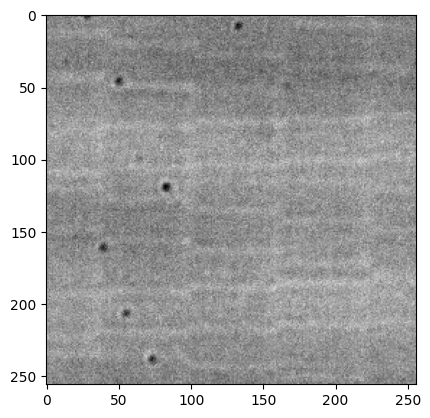

In [96]:
img, mask = data[3]
from matplotlib import pyplot as plt
plt.imshow(img[0], cmap='gray')
plt.show()

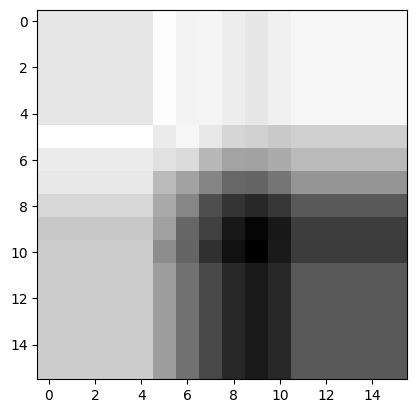

In [107]:
import h5py
hdf5_path = "/scratch/narjis/iscat_data/brightfield_particles_full_volume.hdf5"
with h5py.File(hdf5_path, "r") as f:
    partcile_img = f ["data"][3]
# Normalize image with z-score :mean 7846.924091 , STD 1514.261195
partcile_img = (partcile_img - 7846.924091) / 1514.261195
from matplotlib import pyplot as plt
fig,ax = plt.subplots()
ax.imshow(partcile_img[:,:,0], cmap='gray')
plt.show()

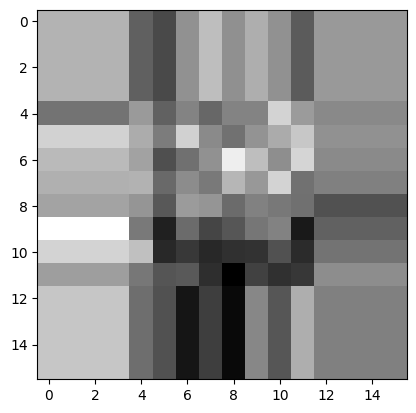

In [106]:
import h5py
hdf5_path = "/scratch/narjis/iscat_data/particles_3d_mf.hdf5"
with h5py.File(hdf5_path, "r") as f:
    partcile_img = f ["data"][3]
# Normalize image with z-score :mean 7846.924091 , STD 1514.261195
# partcile_img = (partcile_img - 7846.924091) / 1514.261195
from matplotlib import pyplot as plt
fig,ax = plt.subplots()
ax.imshow(partcile_img[0], cmap='gray')
plt.show()

In [97]:
import h5py
hdf5_path = "/scratch/narjis/iscat_data/brightfield_particles_full_volume.hdf5"
with h5py.File(hdf5_path, "r") as f:
    partcile_img = f ["data"][3]  # Change shape to (Z, H, W)
partcile_img = (partcile_img - 7846.924091) / 1514.261195

In [71]:
import torch
partcile_img.shape

(201, 16, 16)

In [85]:
img.permute(1,2,0).shape

torch.Size([256, 256, 201])

In [101]:
import numpy as np

def insert_fake_particle(image, mask, particle_vol, particle_cls, max_retries=100):
    """
    Inserts a 3D particle volume into a 3D image at a random empty location.

    Args:
        image (np.ndarray): Source image volume, shape (H, W, Z) (e.g., 256, 256, 201).
        mask (np.ndarray): Segmentation mask, shape (H, W). Values: 0=bg, 1,2..=particles.
        particle_vol (np.ndarray): Particle volume to insert, shape (h, w, Z) (e.g., 16, 16, 201).
        particle_cls (int): Class ID for the new particle (e.g., 3).
        max_retries (int): Maximum attempts to find a non-overlapping spot.

    Returns:
        tuple: (new_image, new_mask, fake_mask)
            - new_image: Image with particle inserted (H, W, Z).
            - new_mask: Updated class mask (H, W).
            - fake_mask: Binary mask of the inserted particle (H, W).
            
    Raises:
        RuntimeError: If a valid empty spot cannot be found after max_retries.
    """
    # 1. Get Dimensions
    H, W, Z = image.shape
    h_p, w_p, z_p = particle_vol.shape

    if Z != z_p:
        raise ValueError(f"Depth mismatch: Image is {Z}, Particle is {z_p}")

    # 2. Iterate to find a valid spot
    for _ in range(max_retries):
        # Random top-left coordinate
        y = np.random.randint(0, H - h_p + 1)
        x = np.random.randint(0, W - w_p + 1)

        # 3. Check for collision
        # We look at the region in the mask where we want to put the particle.
        # It must be all zeros (background).
        roi_mask = mask[y : y + h_p, x : x + w_p]
        
        if np.all(roi_mask == 0):
            # 4. Success: Copy data to avoid mutating originals
            new_image = image.copy()
            new_mask = mask.copy()
            fake_mask = np.zeros_like(mask, dtype=np.uint8)

            # 5. Dump the particle
            # Overwrite image region with particle volume
            new_image[y : y + h_p, x : x + w_p, :] = particle_vol

            # Update segmentation mask with new class
            new_mask[y : y + h_p, x : x + w_p] = particle_cls

            # Update fake mask (1 where the new particle is)
            fake_mask[y : y + h_p, x : x + w_p] = 1

            return new_image, new_mask, fake_mask

    raise RuntimeError("Could not find an empty spot for the particle after multiple attempts.")
def insert_fake_particle_additive(image, mask, particle_vol, particle_cls, max_retries=100):
    H, W, Z = image.shape
    h_p, w_p, z_p = particle_vol.shape
    
    # 1. Estimate particle background (simple approach: median of perimeter)
    # This assumes the particle is centered and smaller than the volume
    bg_val = np.median(np.concatenate([
        particle_vol[0, :, :], particle_vol[-1, :, :], 
        particle_vol[:, 0, :], particle_vol[:, -1, :]
    ]))
    
    # Create the "signal only" (delta). 
    # Warning: Ensure no negative clipping if your data is uint
    particle_signal = particle_vol - bg_val 

    for _ in range(max_retries):
        y = np.random.randint(0, H - h_p + 1)
        x = np.random.randint(0, W - w_p + 1)
        roi_mask = mask[y : y + h_p, x : x + w_p]

        if np.all(roi_mask == 0):
            new_image = image.copy()
            new_mask = mask.copy()
            fake_mask = np.zeros_like(mask, dtype=np.uint8)

            # ADD the signal to the existing background
            roi = new_image[y : y + h_p, x : x + w_p, :]
            new_image[y : y + h_p, x : x + w_p, :] = roi + particle_signal

            new_mask[y : y + h_p, x : x + w_p] = particle_cls
            fake_mask[y : y + h_p, x : x + w_p] = 1
            return new_image, new_mask, fake_mask

    raise RuntimeError("No spot found.")
out = insert_fake_particle_additive(img.permute(1,2,0).numpy(), mask.argmax(dim=0).numpy(), partcile_img, particle_cls=1)

In [102]:
out[0][:,:,0]

array([[-0.97138083, -0.8815681 , -0.9984567 , ..., -1.0189288 ,
        -0.8313786 , -0.88222843],
       [-1.1978939 , -1.4336524 , -1.2639327 , ..., -1.2758197 ,
        -1.3128015 , -1.4501622 ],
       [-1.2612911 , -1.3405378 , -1.3761986 , ..., -1.3755383 ,
        -1.3194053 , -1.3768591 ],
       ...,
       [-1.3187449 , -1.1701577 , -1.262612  , ..., -1.3656325 ,
        -1.2995937 , -1.3220469 ],
       [-1.1853466 , -1.3253489 , -1.3378962 , ..., -1.288367  ,
        -1.2824236 , -1.2315737 ],
       [-1.1926109 , -1.194592  , -1.2077998 , ..., -1.1628933 ,
        -1.2461022 , -1.3365754 ]], dtype=float32)

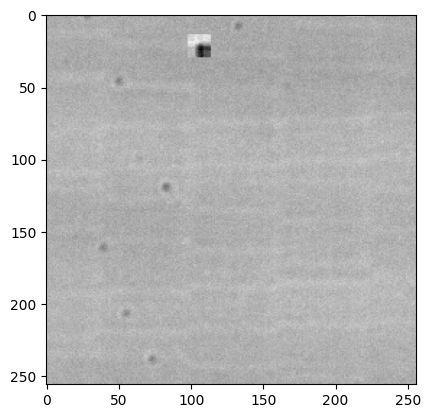

In [104]:

plt.imshow(out[0][:,:,0], cmap='gray')
plt.show()